In [2]:
from dataclasses import dataclass
from pathlib import Path
import os
import sys
import copy
import matplotlib.pyplot as plt
import numpy as np
import yaml
from scipy.ndimage import gaussian_filter1d

ENV = os.getenv('MY_ENV', 'tiziano_mac_mini')
PROJECT_ROOT = Path('../..').resolve()
with open(PROJECT_ROOT / 'config.yaml', 'r') as file:
    config = yaml.safe_load(file)
# end with open

paths = config[ENV]['paths']
sys.path.extend([paths['src_path'], paths['useful_stuff_path']])

from image_processing.video_feature_extraction import (
    list_video_feature_files, load_aligned_video_features,
)
from project_specific_utils import (
    load_natraster, match_timed_static_movie_rasters, min_max_normalization,
    split_half_filename_suffix,
)

In [121]:
@dataclass
class Cfg:
    vid_exp_name: str =  "baby1_260716to24" #    "red_20260720to24" #  
    img_exp_name: str = "baby1_260718to27" #   "red_20260726to27" # 

    # MATLAB channel numbers are one-based and both endpoints are inclusive.
    good_channels: tuple[int, int] | None = (84, 186) #None # None # (101,109) # 
    top_k: int | None = None # 50
    # Intersect good_channels with the image-session reliability config.
    use_reliable_channels: bool = True
    reliable_channels_config: Path | None = None
    reliable_channels_key: str | None = None
    smoothing = 3
    image_crop_ms: int = 1000
    image_time_bin_ms: int = 100
    new_fs: float | None = 100  # Set to None to keep the original 1000 Hz.
    normalization: str | None = None  # Supported: None or 'min_max'.
    signal_RDM_metric: str = 'magnitude_diff'
    model_RDM_metric: str = 'cosine_cnt'
    RSA_metric: str = 'spearman'
    video_RSA_metric: str = 'spearman'
    video_lag_analysis_end_ms: float = 2500
    video_max_lag_ms: float = 700
    video_plot_end_ms: float = 3500
    image_2000ms_onset_ms: float = 2000
    image_2250ms_onset_ms: float = 2250
    last_frame_onset_ms: float = 2500
    residual_conditions: tuple[str, ...] = ('2000ms', '2250ms')
    residual_delay_embedding_lags: tuple[int, int] = (-1, 1)
    residual_regression_type: str = 'lr'
    split_half_frame_timings: tuple[str, ...] = (
        'last_frame', '2000ms', '2250ms',
    )
    split_half_results_dir: Path | None = None
    split_half_feature_centering: bool = True
    split_half_use_spearman_brown: bool = True
    split_half_spearman_brown_k: float = 2
    split_half_static_reference_window_ms: tuple[float, float] = (0, 1000)
    model_name: str = 'ijepa_vith14_1k' #"dino_v3_h" #'vjepa2_vitl_fpc64_256'
    model_dataset_name: str = 'static_dynamic'
    model_pooling: str | None = 'mean'
    model_features_dir: Path | None = None
    example_layer = 1
    linewidth=3
    figs_dir = f"{paths['data_path']}/results/figs_presentation"
    ticks_size = 20
    label_size = 25
    fig_save = True
    frame_500_color  ="#7596C5"
    frame_250_color = "#4A78B5"
    # frame_250_color = "#4673B2"
    # static_color  = "#3969AC"
    static_color = "#3474BD"
    dynamic_color =  "#7F3C8D"# "#A064D6"

cfg = Cfg()
cfg
vid_natraster_mat_path: Path = Path(f"{paths['data_path']}/data") / f'{cfg.vid_exp_name}_natraster_vid.mat'
img_natraster_mat_path: Path = Path(f"{paths['data_path']}/data") / f'{cfg.img_exp_name}_natraster_img.mat'


In [122]:
reliable_channels_config = None
reliable_channels_key = None
if cfg.use_reliable_channels:
    reliable_channels_config = (
        cfg.reliable_channels_config
        or PROJECT_ROOT / 'reliable_channels.yaml'
    )
    # The image-session reliability selection is reused for the movie.
    reliable_channels_key = cfg.reliable_channels_key or cfg.img_exp_name
# end if cfg.use_reliable_channels

loaded_vid_rasters, vid_stimulus_names, vid_channel_numbers = load_natraster(
    vid_natraster_mat_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
loaded_img_rasters, img_stimulus_names, img_channel_numbers = load_natraster(
    img_natraster_mat_path,
    good_channels=cfg.good_channels,
    reliable_channels_config=reliable_channels_config,
    reliable_channels_key=reliable_channels_key,
    return_channel_numbers=True,
)
if not np.array_equal(img_channel_numbers, vid_channel_numbers):
    raise ValueError('Image and movie sessions retained different channels.')
# end if channel numbers differ
loaded_channel_numbers = img_channel_numbers


In [123]:
avg_img_raster = np.mean(loaded_img_rasters, axis=(0,2))
avg_vid_raster = np.mean(loaded_vid_rasters, axis=(0,2))

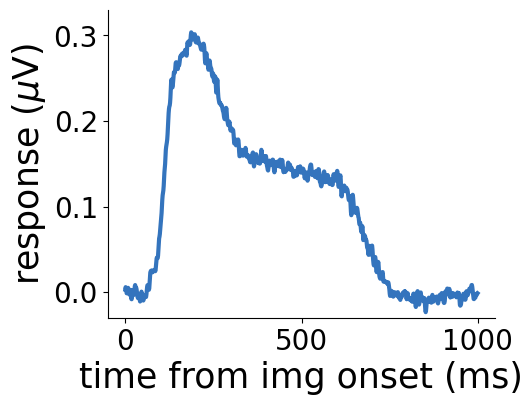

In [133]:
base_width = 5
base_n = 1000

width = base_width * len(avg_img_raster) / base_n

fig, ax = plt.subplots(figsize=(width, 4))

ax.plot(avg_img_raster, linewidth=3, color=cfg.static_color)
ax.tick_params(axis="both", labelsize=cfg.ticks_size)
ax.set_xlabel("time from img onset (ms)", fontsize=cfg.label_size)
ax.set_ylabel(r"response ($\mu$V)", fontsize=cfg.label_size)

ax.set_ylim([-0.03, .33])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
if cfg.fig_save:
    fig.savefig(f"{cfg.figs_dir}/example_img_response.pdf",
            bbox_inches="tight")

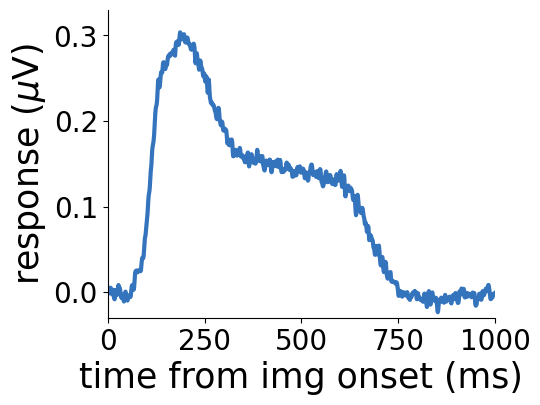

In [137]:
base_width = 5
base_n = 1000

width = base_width * len(avg_img_raster) / base_n
image_times_ms = np.arange(len(avg_img_raster))

# Divide the response into consecutive time bins, including a shorter final bin.
time_bin_edges_ms = np.arange(
    0, len(avg_img_raster), cfg.image_time_bin_ms,
)
time_bin_edges_ms = np.append(time_bin_edges_ms, len(avg_img_raster))
time_bin_centers_ms = (time_bin_edges_ms[:-1] + time_bin_edges_ms[1:]) / 2
# Sample the plotted line at each bin center so every dot lies on the curve.
time_bin_center_response = np.interp(
    time_bin_centers_ms, image_times_ms, avg_img_raster,
)

fig, ax = plt.subplots(figsize=(width, 4))

# Plot the full-resolution response beneath the 100 ms bin-center markers.
ax.plot(
    image_times_ms, avg_img_raster, linewidth=3, color=cfg.static_color,
)
# for time_bin_edge_ms in time_bin_edges_ms:
#     ax.axvline(
#         time_bin_edge_ms, color="0.6", linestyle="--",
#         linewidth=1, alpha=0.8, zorder=0,
#     )
# end for time_bin_edge_ms
# ax.scatter(
#     time_bin_centers_ms, time_bin_center_response, s=150,
#     color=cfg.static_color, edgecolor="white", linewidth=1, zorder=5,
# )
ax.tick_params(axis="both", labelsize=cfg.ticks_size)
ax.set_xlabel("time from img onset (ms)", fontsize=cfg.label_size)
ax.set_ylabel(r"response ($\mu$V)", fontsize=cfg.label_size)

ax.set_xlim([0, len(avg_img_raster)])
ax.set_ylim([-0.03, .33])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
if cfg.fig_save:
    fig.savefig(
        f"{cfg.figs_dir}/example_img_response.pdf",
        bbox_inches="tight",
    )

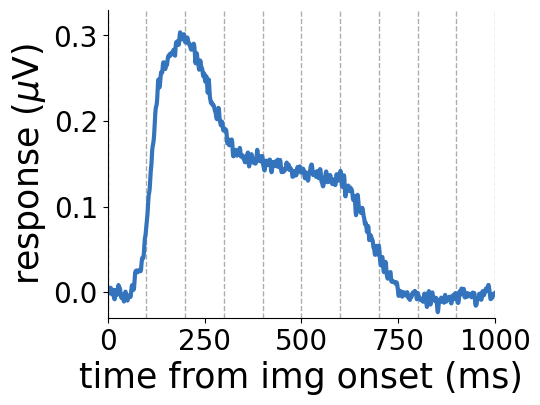

In [138]:
base_width = 5
base_n = 1000

width = base_width * len(avg_img_raster) / base_n
image_times_ms = np.arange(len(avg_img_raster))

# Divide the response into consecutive time bins, including a shorter final bin.
time_bin_edges_ms = np.arange(
    0, len(avg_img_raster), cfg.image_time_bin_ms,
)
time_bin_edges_ms = np.append(time_bin_edges_ms, len(avg_img_raster))
time_bin_centers_ms = (time_bin_edges_ms[:-1] + time_bin_edges_ms[1:]) / 2
# Sample the plotted line at each bin center so every dot lies on the curve.
time_bin_center_response = np.interp(
    time_bin_centers_ms, image_times_ms, avg_img_raster,
)

fig, ax = plt.subplots(figsize=(width, 4))

# Plot the full-resolution response beneath the 100 ms bin-center markers.
ax.plot(
    image_times_ms, avg_img_raster, linewidth=3, color=cfg.static_color,
)
for time_bin_edge_ms in time_bin_edges_ms:
    ax.axvline(
        time_bin_edge_ms, color="0.6", linestyle="--",
        linewidth=1, alpha=0.8, zorder=0,
    )
# end for time_bin_edge_ms
# ax.scatter(
#     time_bin_centers_ms, time_bin_center_response, s=150,
#     color=cfg.static_color, edgecolor="white", linewidth=1, zorder=5,
# )
ax.tick_params(axis="both", labelsize=cfg.ticks_size)
ax.set_xlabel("time from img onset (ms)", fontsize=cfg.label_size)
ax.set_ylabel(r"response ($\mu$V)", fontsize=cfg.label_size)

ax.set_xlim([0, len(avg_img_raster)])
ax.set_ylim([-0.03, .33])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
if cfg.fig_save:
    fig.savefig(
        f"{cfg.figs_dir}/example_img_response_100ms_timebins.pdf",
        bbox_inches="tight",
    )

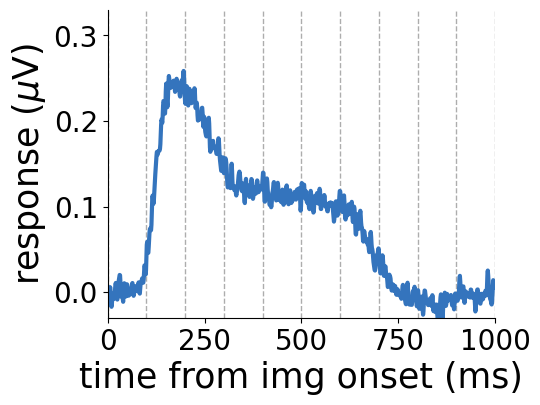

In [148]:
base_width = 5
base_n = 1000

width = base_width * len(avg_img_raster) / base_n
image_times_ms = np.arange(len(avg_img_raster))

# Divide the response into consecutive time bins, including a shorter final bin.
time_bin_edges_ms = np.arange(
    0, len(avg_img_raster), cfg.image_time_bin_ms,
)
time_bin_edges_ms = np.append(time_bin_edges_ms, len(avg_img_raster))
time_bin_centers_ms = (time_bin_edges_ms[:-1] + time_bin_edges_ms[1:]) / 2
# Sample the plotted line at each bin center so every dot lies on the curve.
time_bin_center_response = np.interp(
    time_bin_centers_ms, image_times_ms, avg_img_raster,
)

fig, ax = plt.subplots(figsize=(width, 4))

# Plot the full-resolution response beneath the 100 ms bin-center markers.
ax.plot(
    image_times_ms, np.mean(loaded_img_rasters[20:25, :, :], axis=(0,2)), linewidth=3, color=cfg.static_color,
)
for time_bin_edge_ms in time_bin_edges_ms:
    ax.axvline(
        time_bin_edge_ms, color="0.6", linestyle="--",
        linewidth=1, alpha=0.8, zorder=0,
    )
# end for time_bin_edge_ms
# ax.scatter(
#     time_bin_centers_ms, time_bin_center_response, s=150,
#     color=cfg.static_color, edgecolor="white", linewidth=1, zorder=5,
# )
ax.tick_params(axis="both", labelsize=cfg.ticks_size)
ax.set_xlabel("time from img onset (ms)", fontsize=cfg.label_size)
ax.set_ylabel(r"response ($\mu$V)", fontsize=cfg.label_size)

ax.set_xlim([0, len(avg_img_raster)])
ax.set_ylim([-0.03, .33])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
if cfg.fig_save:
    fig.savefig(
        f"{cfg.figs_dir}/second_example_img_response_100ms_timebins.pdf",
        bbox_inches="tight",
    )

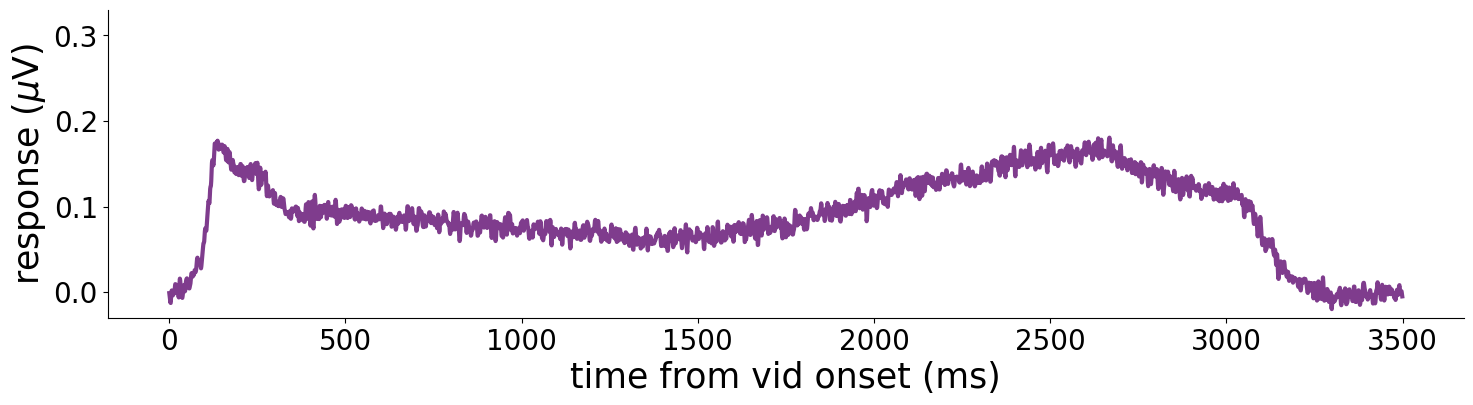

In [125]:
base_width = 5
base_n = 1000

width = base_width * len(avg_vid_raster) / base_n

fig, ax = plt.subplots(figsize=(width, 4))

ax.plot(avg_vid_raster, linewidth=3, color=cfg.dynamic_color)
ax.set_ylim([-0.03, .33])
ax.tick_params(axis="both", labelsize=cfg.ticks_size)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlabel("time from vid onset (ms)", fontsize=cfg.label_size)
ax.set_ylabel(r"response ($\mu$V)", fontsize=cfg.label_size)
if cfg.fig_save:
    fig.savefig(f"{cfg.figs_dir}/example_vid_response.pdf",bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

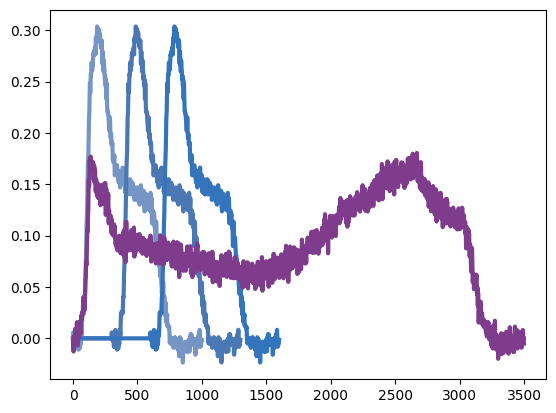

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(avg_img_raster, color=cfg.frame_500_color, linewidth=3)
plt.plot(np.concatenate([np.zeros(300), avg_img_raster]), color=cfg.frame_250_color, linewidth=3)
plt.plot(np.concatenate([np.zeros(600), avg_img_raster]), color=cfg.static_color, linewidth=3)
plt.plot(avg_vid_raster, color=cfg.dynamic_color, linewidth=3)
plt.figure()